# Linear Regression - Practice Notebook


**Regression analysis** lets us **predict one variable using one or more other variables**.
Correlation told us *how strongly* two things are related; regression goes further and builds an
**equation** so we can actually predict a value and measure each factor's influence.

We use it in two ways (from your notes):
1. **Measure the influence** of one variable on another.
2. **Predict** a variable from one or more other variables.

**Two forms covered here:**

| Form | Uses | Equation |
|---|---|---|
| **Simple** linear regression | ONE input variable | y = m·x + c |
| **Multiple** linear regression | TWO or more input variables | y = b0 + b1·x1 + b2·x2 + … |

**Note on libraries:** you only need **NumPy** for the maths (`np.polyfit` for simple,
`np.linalg.lstsq` for multiple) plus pandas/matplotlib/seaborn - no scikit-learn required.

In [2]:
# Run first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/salary_data.csv")   # in Colab, upload the file to /content first
print("Shape:", df.shape)
df.head()


Shape: (120, 6)


,EmployeeID,Age,EducationYears,ExperienceYears,WeeklyHours,Salary_k
0,E001,33,10,12,51,75.7
1,E002,55,18,13,44,89.4
2,E003,47,10,9,46,62.4
3,E004,34,10,9,46,58.6
4,E005,26,12,1,48,65.6


### A helper: R-squared (how good is the fit?)
**R²** tells us what fraction of the variation in salary our model explains, from 0 (useless) to
1 (perfect). We compute it by hand so no extra library is needed. We will reuse this in several
problems.


In [3]:
def r_squared(actual, predicted):
    ss_res = ((actual - predicted) ** 2).sum()          # error left over
    ss_tot = ((actual - actual.mean()) ** 2).sum()      # total variation
    return 1 - ss_res / ss_tot

# quick sanity check: a perfect prediction gives 1.0
print("R2 of a perfect fit:", r_squared(np.array([1,2,3]), np.array([1,2,3])))


R2 of a perfect fit: 1.0


# Part A - Simple Linear Regression (one input)
Predict **Salary** from a **single** variable: **ExperienceYears**.


## Problem 1 - Fit the line (find slope and intercept)

**Problem Statement:** Fit a simple linear regression of `Salary_k` on `ExperienceYears` using
`np.polyfit`. Print the slope (m) and intercept (c) and write the equation. Interpret the slope:
how much does each extra year of experience add to salary?


In [14]:
x = df["ExperienceYears"].values.astype(float)
y = df["Salary_k"].values

# np.polyfit(x, y, 1) fits a degree-1 (straight-line) model and returns [slope, intercept]
m, c = np.polyfit(x, y, 1)
print(f"slope (m)     = {m:.2f}")
print(f"intercept (c) = {c:.2f}")
print(f"\nEquation:  Salary = {m:.2f} * Experience + {c:.2f}")



slope (m)     = 2.13
intercept (c) = 56.11

Equation:  Salary = 2.13 * Experience + 56.11


## Problem 2 - Plot the regression line

**Problem Statement:** Draw the scatter of Experience vs Salary and overlay the fitted line so you
can see the model. (Seaborn's `sns.regplot` can draw the same line automatically.)


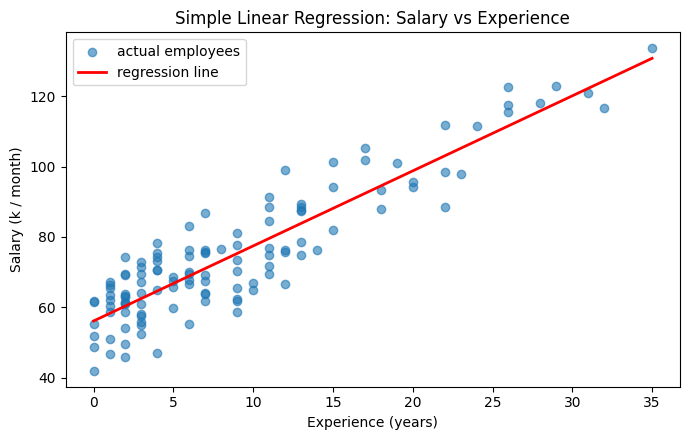

In [5]:
plt.figure(figsize=(7,4.5))
plt.scatter(x, y, alpha=0.6, label="actual employees")
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, m*xs + c, color="red", linewidth=2, label="regression line")
plt.title("Simple Linear Regression: Salary vs Experience")
plt.xlabel("Experience (years)"); plt.ylabel("Salary (k / month)")
plt.legend(); plt.tight_layout(); plt.show()

# Same thing the seaborn way (draws the best-fit line for you):
# sns.regplot(x="ExperienceYears", y="Salary_k", data=df)


## Problem 3 - Make a prediction

**Problem Statement:** Use the equation to predict the salary of a person with **10 years** of
experience. Then predict for **25 years**. This is the whole point of regression - estimating a
value we have not seen.


In [6]:
def predict_salary(exp):
    return m * exp + c

for exp in [10, 25]:
    print(f"Predicted salary for {exp} years experience = {predict_salary(exp):.1f}k / month")


Predicted salary for 10 years experience = 77.4k / month
Predicted salary for 25 years experience = 109.5k / month


## Problem 4 - How good is the fit? (R-squared)

**Problem Statement:** Compute the model's predictions for every employee, then use our
`r_squared` helper to score the fit. Say in words what the number means.


In [7]:
y_pred = m * x + c                 # predictions for all employees
r2 = r_squared(y, y_pred)
print(f"R-squared = {r2:.2f}")
print(f"-> Experience alone explains about {r2*100:.0f}% of the differences in salary.")
print("The rest is due to education, working hours and random factors.")


R-squared = 0.82
-> Experience alone explains about 82% of the differences in salary.
The rest is due to education, working hours and random factors.


## Problem 5 - Residuals (where the model is wrong)

**Problem Statement:** A **residual** is `actual - predicted` for each person - how far off the
model was. Compute residuals, then show the 3 employees the model **underpaid** (most positive
residual) and **overpaid** (most negative). Also plot residuals to check they look random.


Model UNDER-predicted these (actual much higher than predicted):
EmployeeID  ExperienceYears  Salary_k  Predicted  Residual
      E036               12      99.1       81.7      17.4
      E050                7      86.9       71.0      15.9
      E037                6      83.1       68.9      14.2

Model OVER-predicted these:
EmployeeID  ExperienceYears  Salary_k  Predicted  Residual
      E115                4      47.0       64.6     -17.6
      E004                9      58.6       75.3     -16.7
      E103               12      66.5       81.7     -15.2


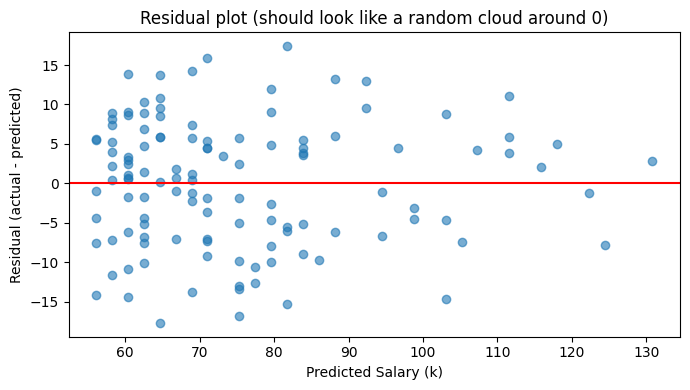

In [8]:
resid = y - y_pred
tmp = df.copy()
tmp["Predicted"] = y_pred.round(1)
tmp["Residual"]  = resid.round(1)

print("Model UNDER-predicted these (actual much higher than predicted):")
print(tmp.nlargest(3, "Residual")[["EmployeeID","ExperienceYears","Salary_k","Predicted","Residual"]].to_string(index=False))
print("\nModel OVER-predicted these:")
print(tmp.nsmallest(3, "Residual")[["EmployeeID","ExperienceYears","Salary_k","Predicted","Residual"]].to_string(index=False))

plt.figure(figsize=(7,4))
plt.scatter(y_pred, resid, alpha=0.6)
plt.axhline(0, color="red", linewidth=1.5)
plt.title("Residual plot (should look like a random cloud around 0)")
plt.xlabel("Predicted Salary (k)"); plt.ylabel("Residual (actual - predicted)")
plt.tight_layout(); plt.show()


In [15]:
tmp

,EmployeeID,Age,EducationYears,ExperienceYears,WeeklyHours,Salary_k,Predicted,Residual
0,E001,33,10,12,51,75.7,81.7,-6.0
1,E002,55,18,13,44,89.4,83.8,5.6
2,E003,47,10,9,46,62.4,75.3,-12.9
3,E004,34,10,9,46,58.6,75.3,-16.7
4,E005,26,12,1,48,65.6,58.2,7.4
...,...,...,...,...,...,...,...,...
115,E116,23,16,2,53,62.8,60.4,2.4
116,E117,55,16,3,51,67.3,62.5,4.8
117,E118,54,10,1,41,51.1,58.2,-7.1
118,E119,31,16,8,43,76.6,73.2,3.4


# Part B - Multiple Linear Regression (many inputs)
Now predict **Salary** from **four** variables at once: Age, EducationYears, ExperienceYears,
WeeklyHours. The equation becomes `Salary = b0 + b1·Age + b2·Edu + b3·Exp + b4·Hours`.
We solve it with `np.linalg.lstsq` (least squares) - still only NumPy.


## Problem 6 - Fit the multiple regression

**Problem Statement:** Build a feature matrix from the four input columns, add a column of 1s for
the intercept, and solve with `np.linalg.lstsq`. Print the intercept and each coefficient.


In [20]:
features = ["Age", "EducationYears", "ExperienceYears", "WeeklyHours"]
X = df[features].values.astype(float)
y = df["Salary_k"].values

# add a column of 1s so the model can learn an intercept (b0)
X_design = np.column_stack([np.ones(len(X)), X])
print(X_design)
# least-squares solution: returns best-fit coefficients
coeffs, *_ = np.linalg.lstsq(X_design, y, rcond=None)

intercept = coeffs[0]
print(f"Intercept (b0) = {intercept:.2f}")
for name, b in zip(features, coeffs[1:]):
    print(f"  {name:16s} coefficient = {b:.2f}")


[[ 1. 33. 10. 12. 51.]
 [ 1. 55. 18. 13. 44.]
 [ 1. 47. 10.  9. 46.]
 [ 1. 34. 10.  9. 46.]
 [ 1. 26. 12.  1. 48.]
 [ 1. 50. 10. 11. 43.]
 [ 1. 36. 12.  5. 52.]
 [ 1. 43. 10. 15. 42.]
 [ 1. 44. 21.  2. 33.]
 [ 1. 32. 21.  4. 46.]
 [ 1. 35. 12. 14. 44.]
 [ 1. 55. 18. 22. 50.]
 [ 1. 49. 10. 13. 49.]
 [ 1. 53. 16.  9. 46.]
 [ 1. 26. 21.  0. 46.]
 [ 1. 35. 16. 13. 46.]
 [ 1. 24. 12.  3. 41.]
 [ 1. 57. 12. 35. 38.]
 [ 1. 45. 21. 12. 40.]
 [ 1. 30. 16.  5. 44.]
 [ 1. 51. 10.  9. 31.]
 [ 1. 50. 15. 24. 42.]
 [ 1. 33. 16.  7. 39.]
 [ 1. 46. 21.  7. 44.]
 [ 1. 25. 21.  1. 40.]
 [ 1. 38. 15.  6. 45.]
 [ 1. 41. 12. 13. 44.]
 [ 1. 23. 18.  2. 53.]
 [ 1. 49. 21.  3. 43.]
 [ 1. 54. 15. 31. 44.]
 [ 1. 47. 10. 20. 45.]
 [ 1. 42. 21. 17. 34.]
 [ 1. 57. 12.  7. 39.]
 [ 1. 36. 21.  2. 54.]
 [ 1. 36. 21. 11. 48.]
 [ 1. 34. 21. 12. 46.]
 [ 1. 38. 18.  6. 51.]
 [ 1. 45. 12.  2. 44.]
 [ 1. 39. 12.  6. 44.]
 [ 1. 34. 21. 11. 43.]
 [ 1. 43. 15. 18. 34.]
 [ 1. 40. 15.  4. 51.]
 [ 1. 24. 16.  0. 44.]
 [ 1. 35. 1

##Why the 1? Because of the intercept b0 — the "starting salary" in the equation that isn't multiplied by any variable. To let the math handle b0 like every other coefficient, we pair it with a column that's always 1 (since b0 × 1 = b0). So that leading 1 is just a placeholder so the intercept fits neatly into the same calculation. It's a standard trick.

## Problem 7 - Interpret the coefficients

**Problem Statement:** Each coefficient means "how much salary changes when that variable goes up
by 1, holding the others fixed." Rank the input variables by the size of their coefficient and say
which factor matters most - and which barely matters.


In [10]:
coef_series = pd.Series(coeffs[1:], index=features).sort_values(key=abs, ascending=False)
print("Coefficients ranked by size of effect on salary:\n")
print(coef_series.round(2))
print(f"\nBiggest driver of salary : {coef_series.index[0]}")
print(f"Weakest driver of salary : {coef_series.index[-1]}")
print("\n(A coefficient near 0, like Age, means it adds little once experience is included.)")


Coefficients ranked by size of effect on salary:

ExperienceYears    2.25
EducationYears     1.58
WeeklyHours        0.48
Age               -0.01
dtype: float64

Biggest driver of salary : ExperienceYears
Weakest driver of salary : Age

(A coefficient near 0, like Age, means it adds little once experience is included.)


## Problem 8 - Predict for a new employee

**Problem Statement:** Predict the salary of a new person: Age 30, EducationYears 16,
ExperienceYears 5, WeeklyHours 45. Build their feature row (starting with 1 for the intercept) and
multiply by the coefficients.


In [11]:
new_person = np.array([1, 30, 16, 5, 45])     # 1 for intercept, then the 4 features in order
predicted = new_person @ coeffs                # dot product = b0 + b1*Age + ...
print("New employee -> Age 30, Edu 16 yrs, Exp 5 yrs, 45 hrs/week")
print(f"Predicted salary = {predicted:.1f}k / month")


New employee -> Age 30, Edu 16 yrs, Exp 5 yrs, 45 hrs/week
Predicted salary = 68.0k / month


## Problem 9 - Simple vs Multiple (which is better?)

**Problem Statement:** Compute R² for the multiple-regression model and compare it with the simple
model from Problem 4 (experience only). Does using more variables explain more of the salary?


In [12]:
y_pred_multi = X_design @ coeffs
r2_multi = r_squared(y, y_pred_multi)

# simple model (experience only) again, for comparison
m_s, c_s = np.polyfit(df["ExperienceYears"], y, 1)
r2_simple = r_squared(y, m_s*df["ExperienceYears"].values + c_s)

print(f"Simple  (experience only) R2 = {r2_simple:.2f}")
print(f"Multiple (4 variables)    R2 = {r2_multi:.2f}")
print(f"\nUsing more variables explained an extra {(r2_multi-r2_simple)*100:.0f}% of salary variation.")


Simple  (experience only) R2 = 0.82
Multiple (4 variables)    R2 = 0.93

Using more variables explained an extra 11% of salary variation.


## Problem 10 - Predicted vs Actual plot

**Problem Statement:** For the multiple-regression model, plot predicted salary against actual
salary. If the model is good, points hug the diagonal line. Add the perfect-prediction line.


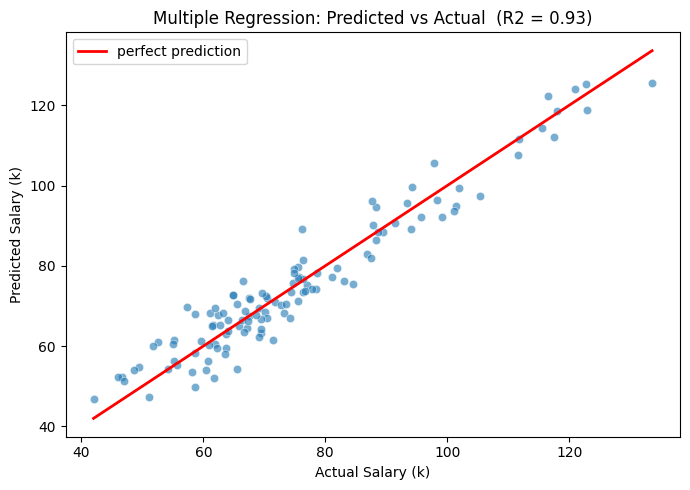

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=y, y=y_pred_multi, alpha=0.6)
lims = [y.min(), y.max()]
plt.plot(lims, lims, color="red", linewidth=2, label="perfect prediction")
plt.title(f"Multiple Regression: Predicted vs Actual  (R2 = {r2_multi:.2f})")
plt.xlabel("Actual Salary (k)"); plt.ylabel("Predicted Salary (k)")
plt.legend(); plt.tight_layout(); plt.show()

# closeness to the red line = quality of the model


---
### Summary
- **Simple regression** predicts from ONE variable → line `y = m·x + c` (`np.polyfit`).
- **Multiple regression** predicts from MANY variables → `y = b0 + b1·x1 + …` (`np.linalg.lstsq`).
- **Slope / coefficients** = influence of each variable; **intercept** = starting value.
- **R²** = how much of the variation the model explains (0 to 1).
- **Residuals** = actual − predicted; they show where the model is wrong.
- More useful variables usually raise R² (multiple beat simple here).

**Remember:** regression finds the best-fit relationship in *this* data - it predicts, but does not
prove that a variable *causes* the outcome.
